#Carga de datos

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



(imgs_train,labs_train), (imgs_test,labs_test) = fashion_mnist.load_data()
print(imgs_train.shape)
print(imgs_test.shape)
nombres = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(10000, 28, 28)


En esta sección se inicializa el entorno de trabajo y se preparan los datos para la red neuronal:

Librerías: Se cargan tensorflow.keras, numpy, pandas y matplotlib. Estas son esenciales para construir el modelo, manipular arreglos numéricos y visualizar resultados.

Carga del Dataset: Se utiliza fashion_mnist.load_data() para obtener el conjunto de datos de entrenamiento (60,000 imágenes) y prueba (10,000 imágenes) de 28x28 píxeles.

Definición de Etiquetas: Se crea una lista llamada nombres que mapea los índices numéricos a categorías de ropa legibles (ej: 'Camiseta/Top', 'Bolso', 'Botín').

# Visualizacion

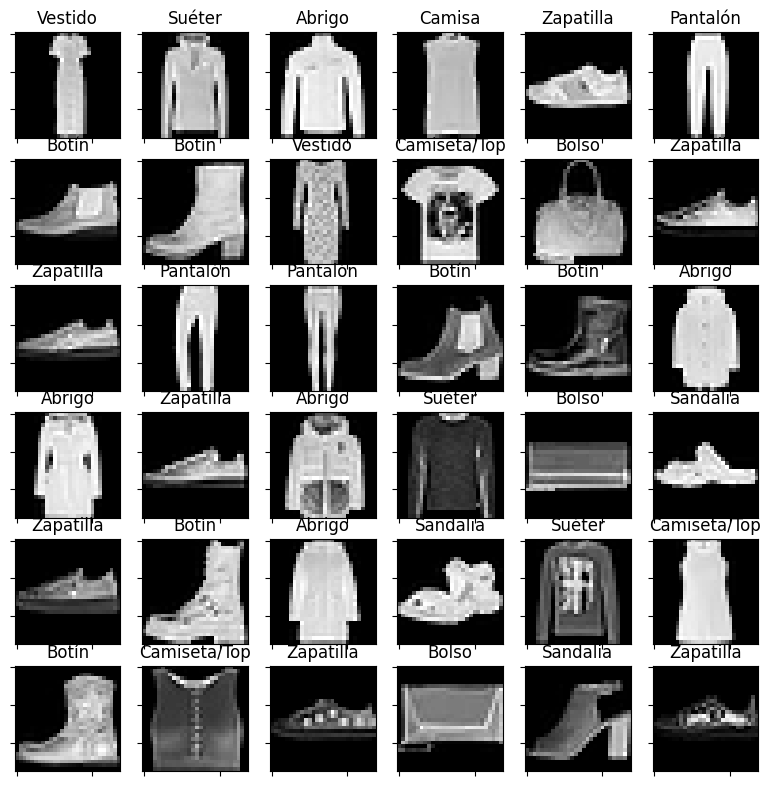

In [ ]:
h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(1.6*h,1.6*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(imgs_test))
    axs[i,j].set_title(nombres[labs_test[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(imgs_test[ex], cmap='gray')

Aqui se crea una cuadrícula de 6x6 (36 imágenes) usando plt.subplots.

 Ademas, se utiliza np.random.randint para seleccionar imágenes al azar del set de prueba, mostrando la imagen en escala de grises (cmap='gray') y asignando su etiqueta correspondiente como título. Esto permite validar visualmente que los datos se cargaron correctamente.

# division datos train y test junto a transformacion a vector

In [ ]:
# Tranformamos los datos para el entrenamiento,
# Necesitamos transformar tanto el train como el test

X_train = imgs_train.reshape(60000,28*28)
X_test = imgs_test.reshape(10000,28*28)
X_train = X_train / 255
X_test = X_test / 255
print('X', X_train.shape, X_test.shape)

Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (60000, 784) (10000, 784)
Y (60000, 10) (10000, 10)


En este módulo, se realiza la preparación del espacio de características. La vectorización adapta la geometría de los datos a la arquitectura MLP, la normalización garantiza la eficiencia del descenso de gradiente al mantener los pesos en rangos controlados, y las etiquetas (One-Hot) permite que la función de costo evalúe correctamente la probabilidad de pertenencia a cada una de las 10 categorías de Fashion MNIST.

Sin estos pasos, el modelo tendría un desempeño significativamente inferior o incluso fallaría al intentar entrenar.

# Primer modelo (descenso del gradiente, 4 layers)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Se fija una semilla o números "aleatorios" iniciales para que sean siempre los mismos cada vez que se ejecuta el código.

Lo que nos garantiza la reproducibilidad. Sin esto, cada vez que se entrenara el modelo se obtendria resultados distintos. Se crea el modelo base de tipo feed forward, donde la información fluye exclusivamente hacia adelante a través de las capas

Capas Ocultas: Utiliza tres capas con funciones de activación ReLU. La ReLU es el estándar de oro aquí porque ayuda a que el modelo aprenda más rápido y evita el desvanecimiento del gradiente.

Capa de Salida: Tiene 10 neuronas con activación Softmax. Esto convierte las salidas de la red en una distribución de probabilidad (la suma de las 10 salidas será 1), permitiendo clasificar la entrada en una de las 10 categorías posibles dichas anteriormente.

Para este primer modelo, se construyo una red neuronal básica dividida en cuatro capas. La estructura comienza recibiendo los datos de entrada y pasándolos por capas ocultas de 512 y 256 neuronas, lo que permite que el modelo "aprenda" patrones importantes de forma gradual. Usamos la función ReLU en estas capas porque ayuda a que el entrenamiento sea más rápido y eficiente, mientras que en la última capa usamos Softmax para que el resultado final sea una probabilidad que nos indique a qué categoría pertenece el objeto analizado. Finalmente, configuramos el modelo con el optimizador SGD y una función de error Categorical Crossentropy en este caso, con estas herramientas la red podra corregir sus errores paso a paso basándose en los 601,610 parámetros que debera ajustar

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp1_sgd_150ep.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6855 - loss: 1.0282 - val_accuracy: 0.7629 - val_loss: 0.6944
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7975 - loss: 0.5997 - val_accuracy: 0.7970 - val_loss: 0.5795
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8184 - loss: 0.5226 - val_accuracy: 0.8123 - val_loss: 0.5313
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8306 - loss: 0.4857 - val_accuracy: 0.8213 - val_loss: 0.5065
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8381 - loss: 0.4623 - val_accuracy: 0.8255 - val_loss: 0.4903
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8444 - loss: 0.4450 - val_accuracy: 0.8305 - val_loss: 0.4783
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8500 - loss: 0.4311 - val_accuracy: 0.8355 - val_loss: 0.4683
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8543 - loss: 0.4194 - val_accu

En este bloque, se realiza el entrenamiento del modelo, que es el proceso de aprendizaje a partir de los datos. Se configuraron tres parámetros clave: las épocas (150), que son las veces que el modelo revisará el conjunto de datos completo y el tamaño de batch (128), y los datos de validación, que sirven para evaluar qué tan bien está aprendiendo la red. Al ejecutar este código, el modelo entrega un historial de su progreso (guardado en la variable hist)

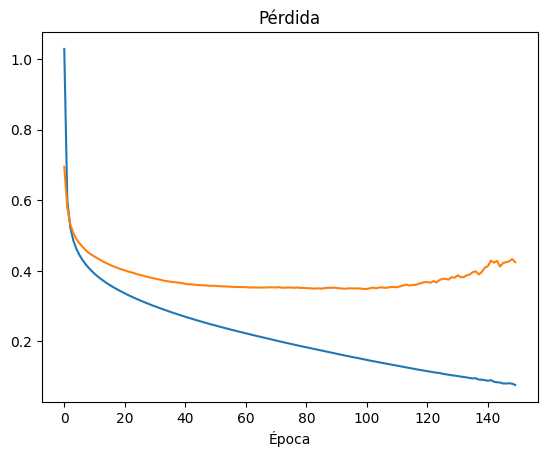

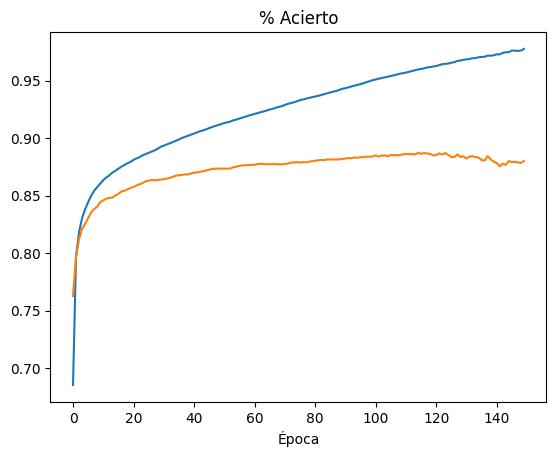

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

A través de estas gráficas, podemos visualizar una comparación entre el aprendizaje con los datos de entrenamiento y los datos de prueba, la gráfica de Pérdida muestra cómo disminuye el error, mientras que la de % Acierto revela qué tan bien está clasificando el modelo a medida que pasan las épocas:

Gráfica de Pérdida (Loss): El entrenamiento baja de forma constante, lo que indicaria que el modelo está aprendiendo a reducir su error interno. por otro lado, la validación deja de bajar cerca de la época 60 y comienza a subir ligeramente al final. Esto nos dice que el modelo se está volviendo muy bueno para memorizar los datos de práctica, pero le está costando mantener esa precisión con datos nuevos

Gráfica de % Acierto: Aqui vemos que el acierto en el entrenamiento llega casi al 95%, pero el acierto en la validación se estanca alrededor del 85%. Esta brecha entre ambas líneas nos indican que existe un overfitting (sobreajuste), lo que indica que el modelo no está generalizando de forma correcta

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.84      0.83      1000
    Pantalón       0.98      0.98      0.98      1000
      Suéter       0.87      0.70      0.78      1000
     Vestido       0.92      0.84      0.88      1000
      Abrigo       0.69      0.93      0.79      1000
    Sandalia       0.97      0.96      0.97      1000
      Camisa       0.74      0.67      0.70      1000
   Zapatilla       0.94      0.96      0.95      1000
       Bolso       0.97      0.96      0.96      1000
       Botín       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



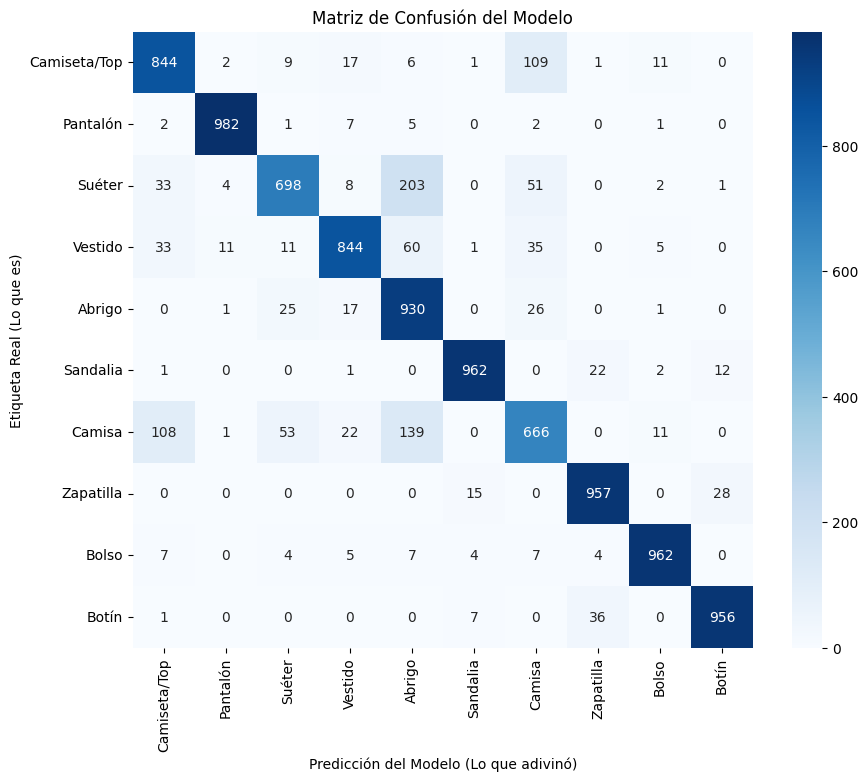

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Por ultimo generamos un Cuadro Resumen de Métricas que nos entrega lo siguiente, la Precisión(que tanto acerto), el Recall (erroneos) y el F1-Score por cada tipo de prenda. Luego lo graficamos en una matriz de confusion,este primer modelo tuvo un desempeño aceptable, logrando una precision general (accuracy) del 89%, siendo eficiente para reconocer prendas fáciles de distinguir como Pantalones y Bolsos, donde alcanzó un 0.98 y 0.96 de precisión. pero presento dificultades con las Camisa (74% ) y el Abrigo(69%), confundiéndolos con Suéteres y Camisetas, como muestra la matriz de confusión.

# Segundo modelo (descenso del gradiente, 4 layers,Dropout)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='sgd',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Para este segundo modelo, hemos mantenido la estructura base del primero pero introduciendo una mejora, la técnica de regularización de Dropout. En este código, añadimos capas de Dropout que "apagan" aleatoriamente un porcentaje de neuronas (30% en la primera capa y 20% en la segunda) durante cada paso del entrenamiento. Hacemos esto para obligar a la red a no depender de neuronas específicas y así evitar que simplemente memorice los datos, evitando que este modelo se sobreajuste que el modelo anterior(primer modelo). Tal como muestra el resumen del modelo, esta pequeña modificación nos da una estrategia de optimización mejor. Al compilar con SGD y Categorical Crossentropy, se preparada una red que busca ser más estable y generalizar mejor ante imágenes nuevas o datos nuevos.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp2_sgd_150ep_Dropout.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5858 - loss: 1.2419 - val_accuracy: 0.7350 - val_loss: 0.7275
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7424 - loss: 0.7316 - val_accuracy: 0.7767 - val_loss: 0.6131
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7783 - loss: 0.6349 - val_accuracy: 0.8010 - val_loss: 0.5569
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7976 - loss: 0.5781 - val_accuracy: 0.8104 - val_loss: 0.5271
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8091 - loss: 0.5448 - val_accuracy: 0.8151 - val_loss: 0.5079
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8168 - loss: 0.5187 - val_accuracy: 0.8242 - val_loss: 0.4874
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8234 - loss: 0.4962 - val_accuracy: 0.8304 - val_loss: 0.4694
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8301 - loss: 0.4808 - va

En este bloque realizamos el entrenamiento del segundo modelo, manteniendo los mismos parámetros de control. La diferencia principal es que, al ejecutar este proceso, el modelo está aplicando activamente el Dropout que se configuro anteriormente, lo que significa que en cada época la red se ve forzada a aprender de una manera más robusta al no poder usar todas sus neuronas al mismo tiempo

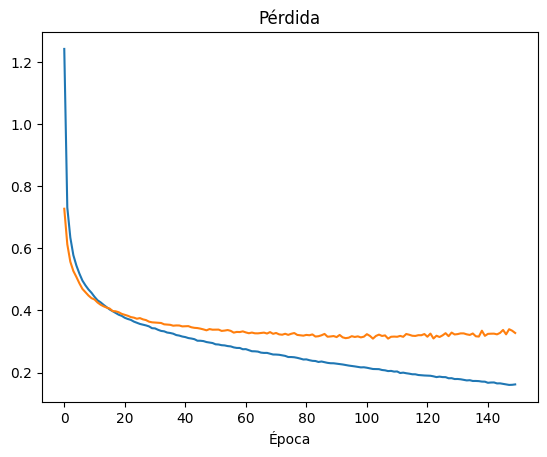

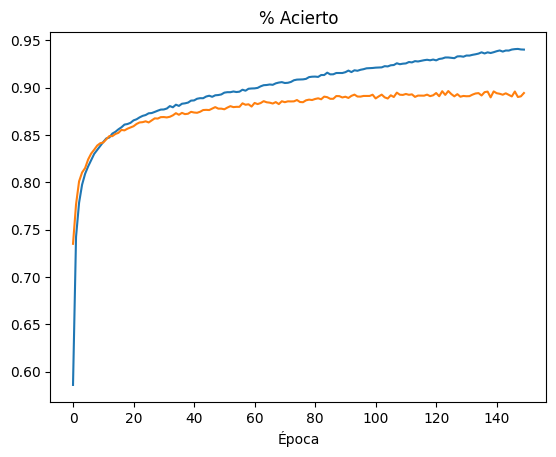

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Este bloque de código genera las gráficas de rendimiento para el segundo experimento, permitiendo ver el impacto de la técnica de Dropout. Al observar las nuevas curvas de Pérdida y % Acierto, se nota un cambio positivo. la línea del entrenamiento y la validación se mantienen mucho más cerca entre sí durante todo el proceso. Lo que nos indica debido al Dropout, logramos reducir significativamente el sobreajuste, ya que la red ya no solo memoriza los datos de practica, sino que ahora es más estable y capaz de mantener un buen desempeño ante información nueva. Por otro lado la grafica de Accuracy la brecha entre el entrenamiento y la validación se redujo notablemente que el primer modelo, lo que significa que nos indicaria que el modelo no se basa en la memorización, sino en una mejor capacidad de identificar patrones generales en las prendas que su predecesor

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.85      0.85      0.85      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.85      0.77      0.81      1000
     Vestido       0.89      0.91      0.90      1000
      Abrigo       0.75      0.90      0.82      1000
    Sandalia       0.97      0.97      0.97      1000
      Camisa       0.76      0.68      0.72      1000
   Zapatilla       0.95      0.96      0.96      1000
       Bolso       0.98      0.97      0.97      1000
       Botín       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



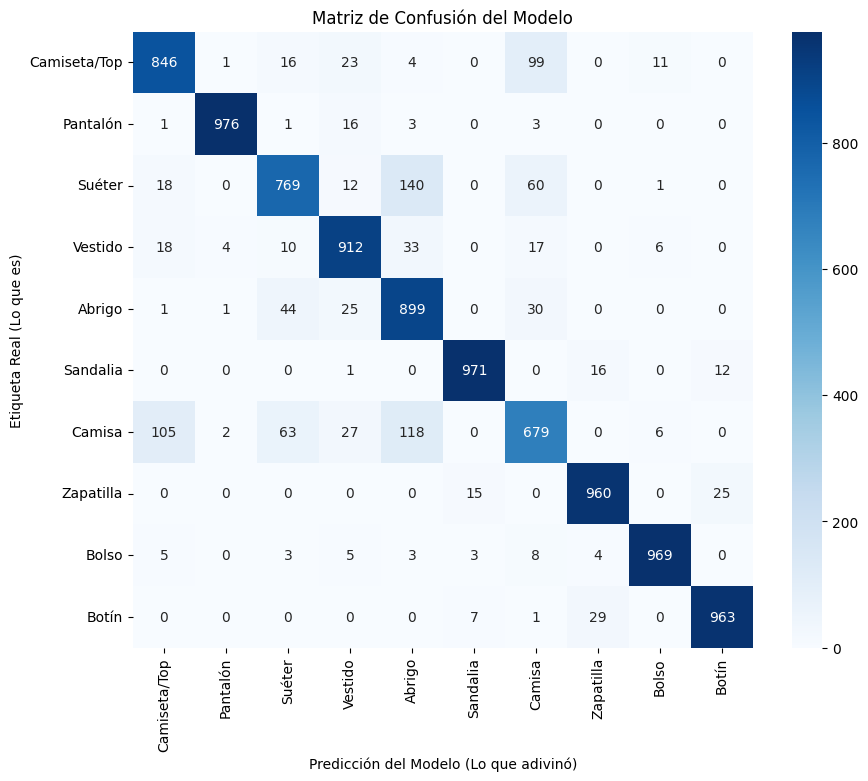

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Este segundo modelo demuestra una mejora en el desempeño al implementar Dropout, siendo fundamental para mitigar el sobreajuste al "apagar" aleatoriamente neuronas durante el entrenamiento. Al analizar las métricas en el cuadro resumen y la matriz de confusión, se observa que la exactitud general subió al 89% y las curvas de aprendizaje se volvieron mucho más estables y cercanas entre sí, lo que confirma que el modelo ahora generaliza mejor en lugar de solo memorizar. En conclusión, este experimento entrega un sistema más robusto y estable que el primero, logrando un mejor equilibrio en la clasificación de prendas complejas como Camisetas y Vestidos

# Tercer modelo (cambio de optimizador a adam)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

En este bloque de código se define el tercer experimento, donde se mantiene la arquitectura robusta con Dropout pero se sustituye el optimizador SGD por Adam. A diferencia de los modelos anteriores, Adam es un optimizador de aprendizaje adaptativo que ajusta automáticamente la tasa de aprendizaje para cada parámetro, dirigiendose de una manera mas rápida y eficiente hacia el error mínimo. Se mantienen los mismos parametros, pero la lógica detrás de cómo la red actualiza sus pesos ahora es mas refinado, buscando maximizar la precisión en menos tiempo y con mayor estabilidad.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp3_adam_150ep.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7989 - loss: 0.5581 - val_accuracy: 0.8298 - val_loss: 0.4751
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8497 - loss: 0.4095 - val_accuracy: 0.8501 - val_loss: 0.4035
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8625 - loss: 0.3729 - val_accuracy: 0.8627 - val_loss: 0.3788
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8713 - loss: 0.3504 - val_accuracy: 0.8611 - val_loss: 0.3743
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8755 - loss: 0.3378 - val_accuracy: 0.8631 - val_loss: 0.3798
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8814 - loss: 0.3230 - val_accuracy: 0.8696 - val_loss: 0.3614
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8848 - loss: 0.3110 - val_accuracy: 0.8728 - val_loss: 0.3506
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8876 - loss: 0.3014 - 

En este bloque se ejecuta el entrenamiento del tercer modelo, manteniendo las 150 épocas y el tamaño de lote de 128 para asegurar una comparación justa con los experimentos anteriores. La diferencia fundamental es la presencia del optimizador Adam, que gestiona de manera inteligente la velocidad de aprendizaje en cada paso del proceso

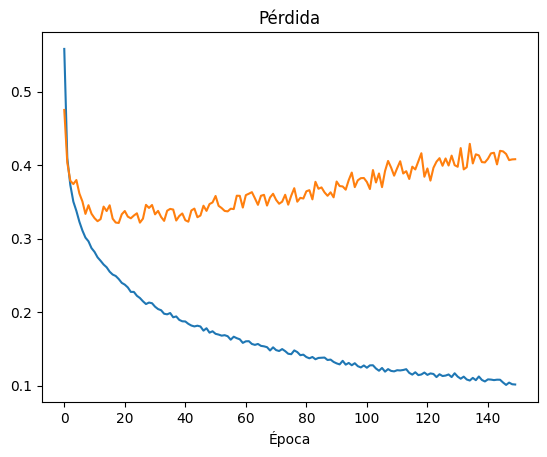

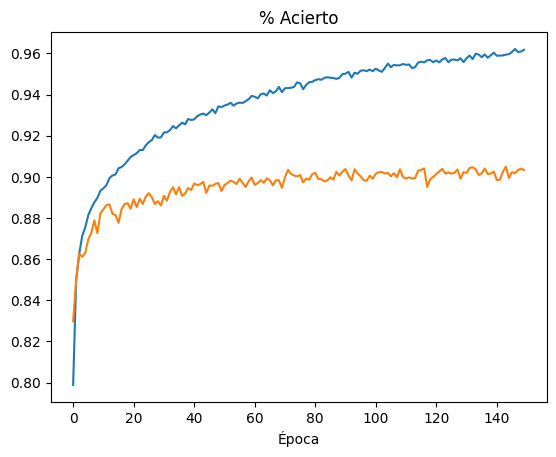

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Al ver los graficos, destaca que el optimizador Adam permite que la red encuentre los mejores resultados de forma mucho más rápida, alcanzando niveles altos de precisión con menos epocas, pero las curvas también muestran una mayor inestabilidad. En el gráfico de Pérdida, la validación presenta oscilaciones y  tiende aumentar después de 20 epocas, lo que puede indicar que, a pesar de ser muy potente "Adam", en este caso u configuracion se genera un sobreajuste (overfitting) mas evidente que los anteriores modelos con SGD y Dropout. Por otro lado, el Accuracy en validación se estabiliza rápidamente alrededor del 90%, pero la brecha con respecto al entrenamiento sugiere que la red ha comenzado a memorizar patrones del conjunto de práctica con mas agresividad.

Podemos concluir que, si bien Adam acelera el aprendizaje, requiere una supervisión mayor o una mayor regularización para evitar que la red pierda estabilidad.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.86      0.85      1000
    Pantalón       0.99      0.98      0.99      1000
      Suéter       0.87      0.81      0.84      1000
     Vestido       0.91      0.92      0.91      1000
      Abrigo       0.82      0.85      0.83      1000
    Sandalia       0.97      0.98      0.98      1000
      Camisa       0.74      0.74      0.74      1000
   Zapatilla       0.95      0.97      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.97      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



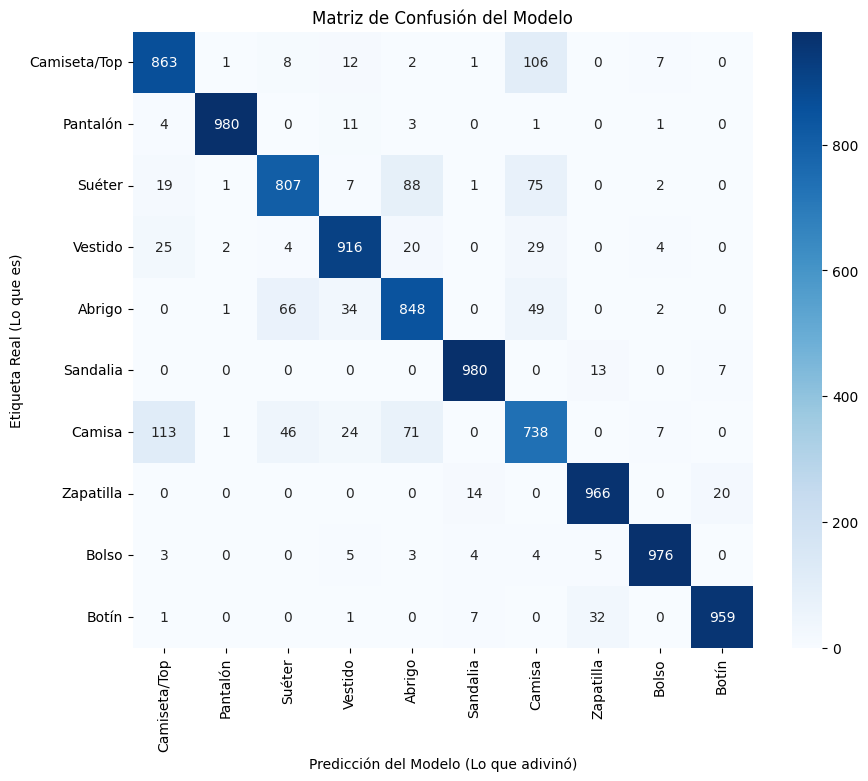

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanzó una precision general (accuracy) del 90%, que sus antecesores. Se observa una mejora notable en el F1-score de categorías que a los modelos les costaba predecir, como el 'Suéter' subió a 0.84 y el 'Abrigo' a 0.83, superando los resultados del modelo con SGD.

Por otro lado en la matriz de confusion la diagonal principal muestra valores más altos de aciertos en casi todas las clases, demostrando que el optimizador Adam permitió a la red encontrar patrones de reconocimiento mejores para estos artículos y reduciendo la perdida.

Podemos decir que, El uso de Adam permitió obtener una precision del 90%, demostrando que un optimizador con tasa de aprendizaje adaptativa es ideal para esta arquitectura de 4 capas con Dropout. Aunque sigue existiendo cierta confusión natural entre prendas similares como Camisa y Camiseta/Top, el modelo es mucho más equilibrado y comete menos errores. Este experimento nos ayuda a evidenciar que la combinación de Dropout (para evitar el sobreajuste) y el optimizador Adam (para acelerar y mejorar el aprendizaje) es una configuracion bastante optima

Sin embargo, a pesar de tener una mayor precision, sus metricas de desempeño revelan una estructura inferior a la del modelo anterior. Al contrastar las gráficas Accuracy y Perdida, se observa una notable inestabilidad en la fase de validación, mostrando oscilaciones bruscas y tendiendo aumentar en la función de pérdida a partir de la época 20. Si bien Adam encuentre los mejores resultados de forma mucho más rápida, tiende a un sobreajuste (overfitting) más agresivo, alejando las curvas de entrenamiento y prueba.

# Cuarto modelo (implementacion de batch normalization)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp4_adam_150_BN.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8172 - loss: 0.5063 - val_accuracy: 0.8413 - val_loss: 0.4424
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8536 - loss: 0.3952 - val_accuracy: 0.8418 - val_loss: 0.4507
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8630 - loss: 0.3679 - val_accuracy: 0.8492 - val_loss: 0.4257
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8690 - loss: 0.3516 - val_accuracy: 0.8699 - val_loss: 0.3643
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8763 - loss: 0.3353 - val_accuracy: 0.8706 - val_loss: 0.3561
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8792 - loss: 0.3240 - val_accuracy: 0.8653 - val_loss: 0.3638
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8836 - loss: 0.3112 - val_accuracy: 0.8732 - val_loss: 0.3652
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8848 - loss: 0.3080 - 

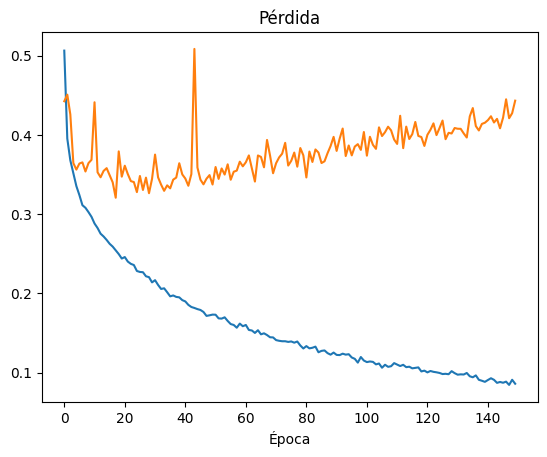

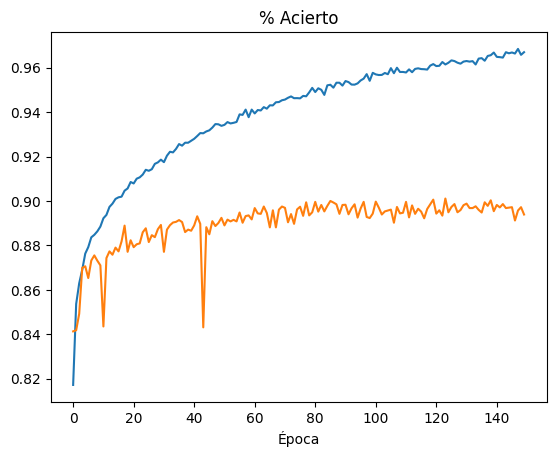

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.85      0.83      1000
    Pantalón       0.99      0.98      0.99      1000
      Suéter       0.80      0.85      0.82      1000
     Vestido       0.86      0.94      0.90      1000
      Abrigo       0.80      0.84      0.82      1000
    Sandalia       0.98      0.97      0.98      1000
      Camisa       0.79      0.63      0.70      1000
   Zapatilla       0.94      0.97      0.96      1000
       Bolso       0.99      0.97      0.98      1000
       Botín       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



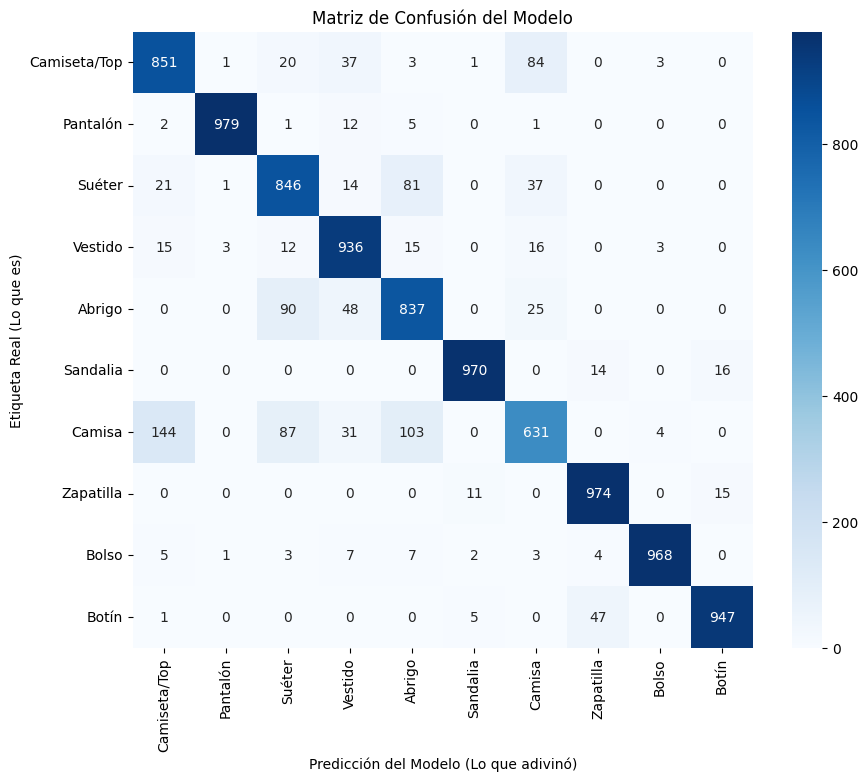

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

# Quinto modelo (disminucion de Batch size)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp5_adam_64_BS.keras')

Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8108 - loss: 0.5203 - val_accuracy: 0.8246 - val_loss: 0.4887
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8484 - loss: 0.4158 - val_accuracy: 0.8426 - val_loss: 0.4387
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8581 - loss: 0.3857 - val_accuracy: 0.8538 - val_loss: 0.4005
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8640 - loss: 0.3695 - val_accuracy: 0.8464 - val_loss: 0.4288
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8698 - loss: 0.3534 - val_accuracy: 0.8260 - val_loss: 0.4610
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8721 - loss: 0.3467 - val_accuracy: 0.8591 - val_loss: 0.3905
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8763 - loss: 0.3307 - val_accuracy: 0.8568 - val_loss: 0.3966
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8807 - loss: 0.3204 - val_

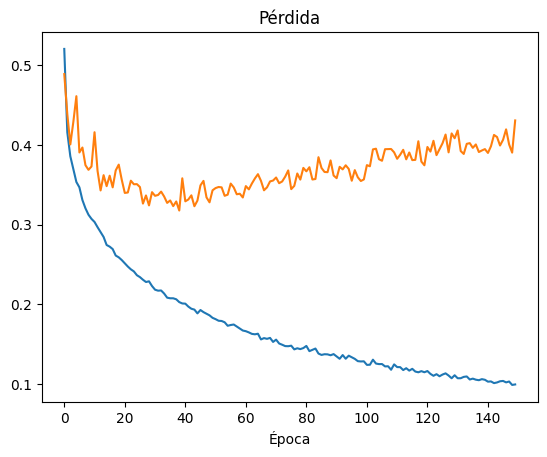

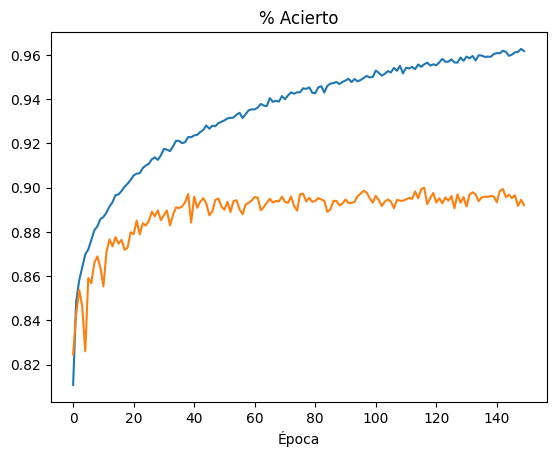

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.88      0.84      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.89      0.76      0.82      1000
     Vestido       0.90      0.90      0.90      1000
      Abrigo       0.73      0.92      0.81      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.78      0.64      0.70      1000
   Zapatilla       0.95      0.95      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.94      0.96      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



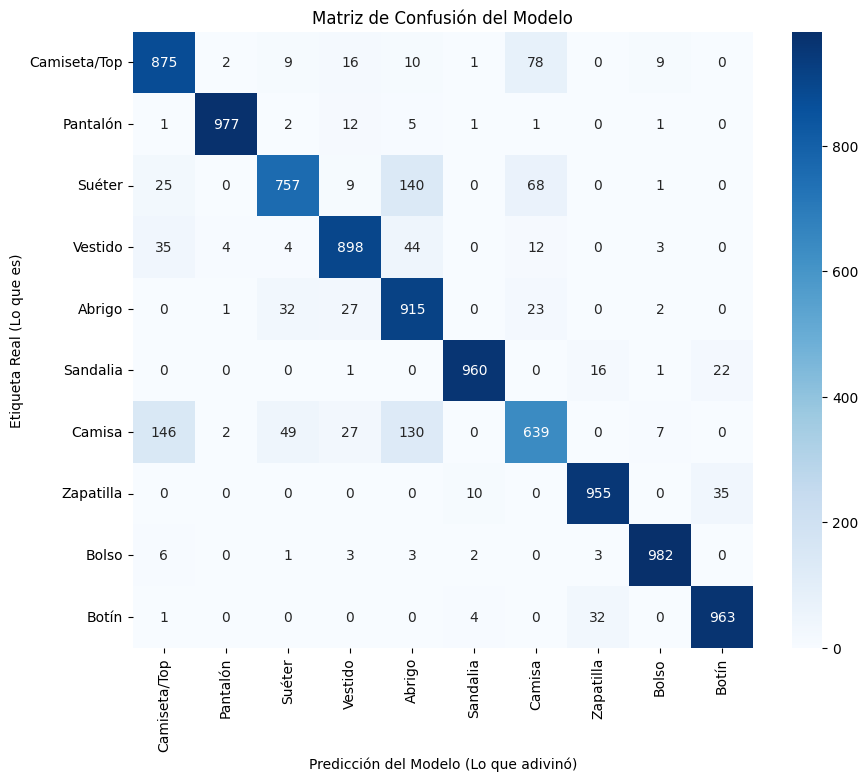

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

# Sexto Modelo Cambio de learning Rate

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp6_learning_rate.keras')

Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8090 - loss: 0.5320 - val_accuracy: 0.8375 - val_loss: 0.4679
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8488 - loss: 0.4124 - val_accuracy: 0.8590 - val_loss: 0.3906
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8598 - loss: 0.3810 - val_accuracy: 0.8443 - val_loss: 0.4420
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8665 - loss: 0.3599 - val_accuracy: 0.8537 - val_loss: 0.3976
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8717 - loss: 0.3450 - val_accuracy: 0.8624 - val_loss: 0.3903
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8775 - loss: 0.3307 - val_accuracy: 0.8608 - val_loss: 0.3865
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8795 - loss: 0.3224 - val_accuracy: 0.8629 - val_loss: 0.3887
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8845 - loss: 0.3087 - 

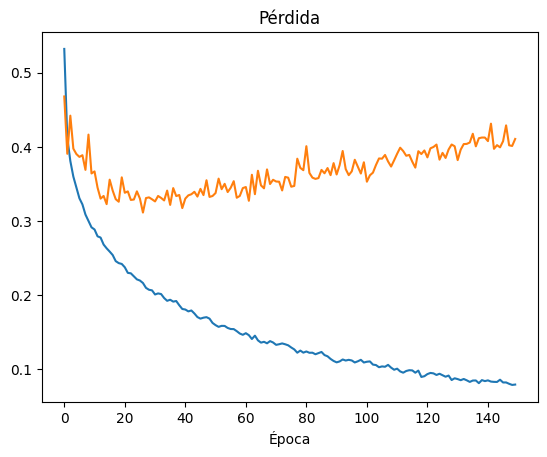

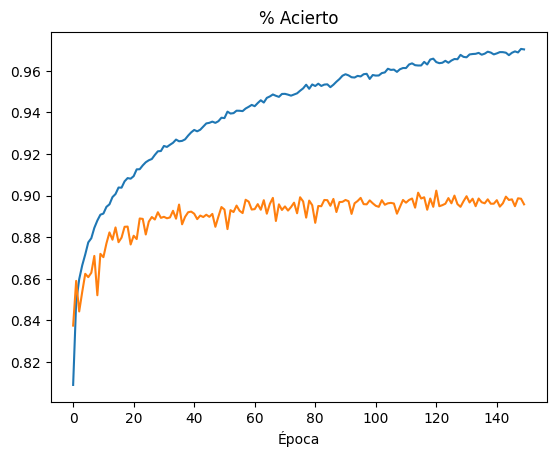

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.87      0.83      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.84      0.83      0.83      1000
     Vestido       0.90      0.91      0.91      1000
      Abrigo       0.80      0.85      0.83      1000
    Sandalia       0.98      0.95      0.97      1000
      Camisa       0.76      0.66      0.71      1000
   Zapatilla       0.93      0.97      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



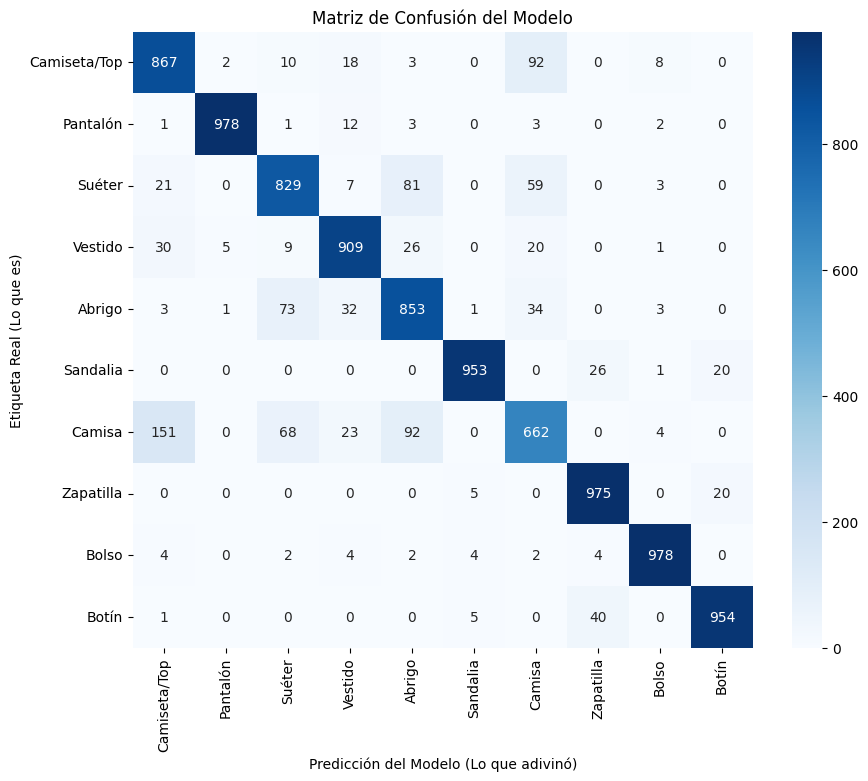

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

#Septimo modelo early stop

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp7_early_stop.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8104 - loss: 0.5300 - val_accuracy: 0.8376 - val_loss: 0.4644
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8493 - loss: 0.4079 - val_accuracy: 0.8536 - val_loss: 0.4033
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8620 - loss: 0.3779 - val_accuracy: 0.8575 - val_loss: 0.4022
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8675 - loss: 0.3587 - val_accuracy: 0.8630 - val_loss: 0.3913
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8753 - loss: 0.3387 - val_accuracy: 0.8558 - val_loss: 0.3972
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8783 - loss: 0.3282 - val_accuracy: 0.8622 - val_loss: 0.3871
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8817 - loss: 0.3191 - val_accuracy: 0.8704 - val_loss: 0.3608
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8844 - loss: 0.3092 - val_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.88      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.81      0.83      0.82      1000
     Vestido       0.87      0.91      0.89      1000
      Abrigo       0.77      0.88      0.82      1000
    Sandalia       0.99      0.95      0.97      1000
      Camisa       0.82      0.56      0.66      1000
   Zapatilla       0.94      0.97      0.95      1000
       Bolso       0.96      0.98      0.97      1000
       Botín       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



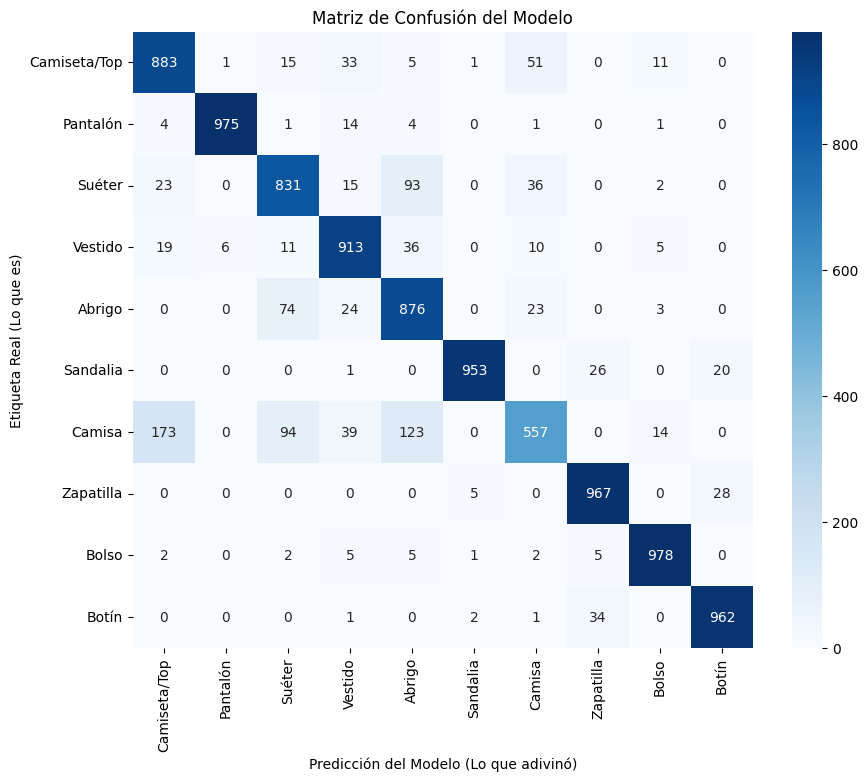

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

#Modelo 8 cambio de funcion de activacion

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp8_sigmoid.keras')

Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8133 - loss: 0.5259 - val_accuracy: 0.8369 - val_loss: 0.4593
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8494 - loss: 0.4161 - val_accuracy: 0.8541 - val_loss: 0.4093
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8636 - loss: 0.3756 - val_accuracy: 0.8580 - val_loss: 0.4050
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8734 - loss: 0.3488 - val_accuracy: 0.8605 - val_loss: 0.3903
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8788 - loss: 0.3277 - val_accuracy: 0.8692 - val_loss: 0.3666
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8852 - loss: 0.3110 - val_accuracy: 0.8654 - val_loss: 0.3776
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8900 - loss: 0.2974 - val_accuracy: 0.8704 - val_loss: 0.3660
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8934 - loss: 0.2871 - val_

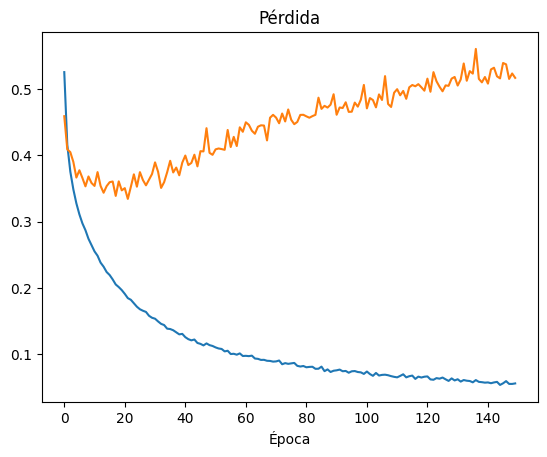

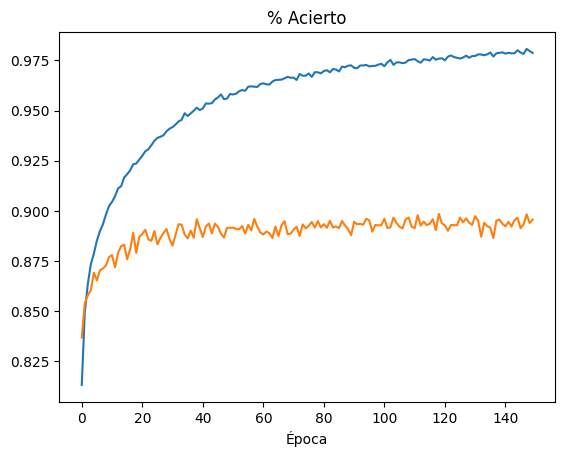

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.86      0.85      1000
    Pantalón       0.98      0.98      0.98      1000
      Suéter       0.81      0.83      0.82      1000
     Vestido       0.90      0.90      0.90      1000
      Abrigo       0.80      0.84      0.82      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.76      0.69      0.72      1000
   Zapatilla       0.93      0.97      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



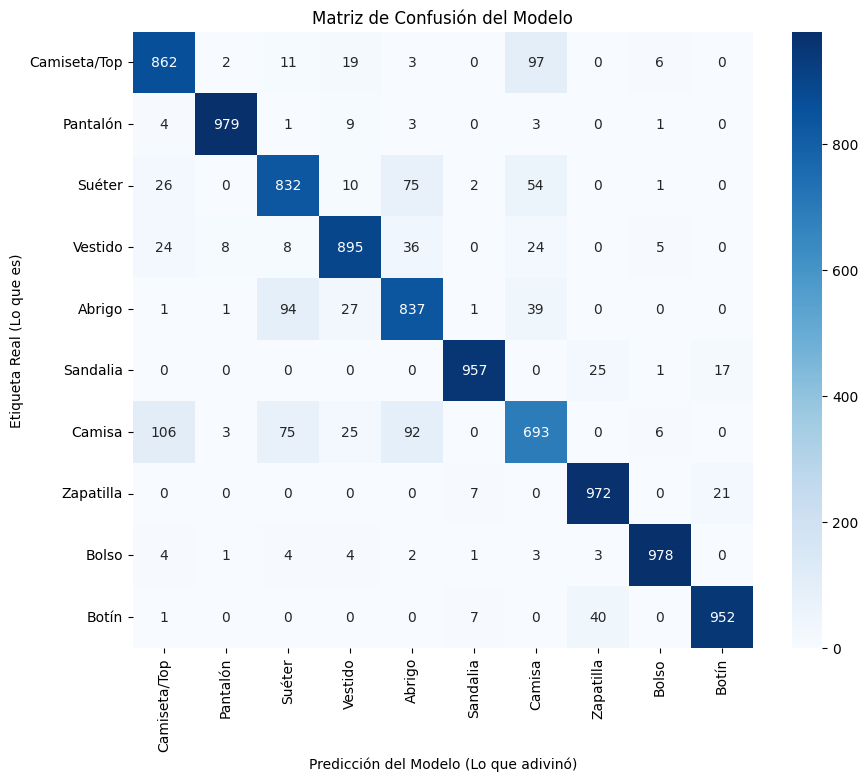

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

# Tabla comparativa

In [ ]:
import pandas as pd
historial_experimentos = []
historial_experimentos.append({
    'Modelo': 'Exp 1: Base',
    'Optimizador': 'SGD',
    'LR': 'Por defecto',
    'Batch Size': 128,
    'Épocas': 150,
    'Train Accuracy': '97.7%',
    'Val Accuracy': '88.0%',
    'Observación Principal': 'Overfitting'
})
historial_experimentos.append({
    'Modelo': 'Exp 2: Dropout',
    'Optimizador': 'SGD',
    'LR': 'Por defecto',
    'Batch Size': 128,
    'Épocas': 150,
    'Train Accuracy': '94%',
    'Val Accuracy': '89,4%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 3: Adam',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 128,
    'Épocas': 150,
    'Train Accuracy': '96,1%',
    'Val Accuracy': '90,3%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 4: Adam',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 128,
    'Épocas': 150,
    'Train Accuracy': '96,7%',
    'Val Accuracy': '89,3%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 5: disminucion Batch size',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 64,
    'Épocas': 150,
    'Train Accuracy': '96,1%',
    'Val Accuracy': '89,2%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 6: disminucion learning rate',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 64,
    'Épocas': 150,
    'Train Accuracy': '97%',
    'Val Accuracy': '89,5%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 7: early stop',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 64,
    'Épocas': 35,
    'Train Accuracy': '97%',
    'Val Accuracy': '89,5%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 8: early stop',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 64,
    'Épocas': 35,
    'Train Accuracy': '92,5%',
    'Val Accuracy': '88,9%',
    'Observación Principal': ''
})
historial_experimentos.append({
    'Modelo': 'Exp 9: early stop',
    'Optimizador': 'adam',
    'LR': 'Por defecto',
    'Batch Size': 64,
    'Épocas': 35,
    'Train Accuracy': '97,8%',
    'Val Accuracy': '89,5%',
    'Observación Principal': ''
})

# Experimentación con Transfer Learning (VGG16)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow import keras
import numpy as np

print("--- Preparando datos para Transfer Learning ---")
# 1. Recuperamos las imágenes originales (sin aplanar)
X_train_cnn = np.expand_dims(imgs_train, axis=-1)
X_test_cnn = np.expand_dims(imgs_test, axis=-1)

# 2. Convertimos a "RGB" falso y redimensionamos a 32x32 usando TensorFlow
X_train_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_train_cnn))
X_train_resized = tf.image.resize(X_train_rgb, [32, 32]) / 255.0

X_test_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_test_cnn))
X_test_resized = tf.image.resize(X_test_rgb, [32, 32]) / 255.0

print("Nuevas dimensiones X:", X_train_resized.shape)

# 3. Cargar el modelo base VGG16 (Preentrenado)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# CONGELAMOS los pesos del modelo base para no destruir su aprendizaje previo
base_model.trainable = False

# 4. Construimos nuestra red agregando el clasificador final
red_tl = keras.Sequential([
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax')
])

red_tl.summary()

# 5. Compilamos y Entrenamos
red_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos solo por 5 épocas, ya que el modelo ya viene "aprendido"
hist_tl = red_tl.fit(
    X_train_resized, Y_train, # Usamos Y_train categórico que ya tenías
    epochs=5,
    batch_size=128,
    validation_data=(X_test_resized, Y_test)
)

--- Preparando datos para Transfer Learning ---
Nuevas dimensiones X: (60000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 862s 2s/step - accuracy: 0.7655 - loss: 0.6685 - val_accuracy: 0.8300 - val_loss: 0.4708
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 872s 2s/step - accuracy: 0.8316 - loss: 0.4685 - val_accuracy: 0.8439 - val_loss: 0.4266
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 860s 2s/step - accuracy: 0.8440 - loss: 0.4269 - val_accuracy: 0.8533 - val_loss: 0.4027
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 882s 2s/step - accuracy: 0.8521 - loss: 0.4019 - val_accuracy: 0.8574 - val_loss: 0.3937
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 864s 2s/step - accuracy: 0.8587 - loss: 0.3863 - val_accuracy: 0.8562 - val_loss: 0.3889
